In [2]:
!kaggle datasets download -d masoudnickparvar/brain-tumor-mri-dataset

Dataset URL: https://www.kaggle.com/datasets/masoudnickparvar/brain-tumor-mri-dataset
License(s): Attribution 4.0 International (CC BY 4.0)
100% 157M/157M [00:00<00:00, 219MB/s]



In [3]:
import zipfile
zip_ref = zipfile.ZipFile('/content/brain-tumor-mri-dataset.zip', 'r')
zip_ref.extractall("/content")
zip_ref.close()

In [4]:
train_dir = '/content/Training'
test_dir = '/content/Testing'

In [5]:
import tensorflow as tf
from tensorflow import keras
from keras.layers import Input, Dense, Dropout, GlobalAveragePooling2D, Flatten, RandomFlip, RandomRotation,RandomZoom, RandomContrast,Rescaling
from keras.optimizers import Adam
from keras.applications import VGG16
from keras.models import Sequential
from keras.preprocessing.image import load_img, img_to_array
from tensorflow.keras import regularizers
from sklearn.utils import shuffle
from keras.applications.vgg16 import preprocess_input
import numpy as np
import os

In [20]:
train_ds = keras.utils.image_dataset_from_directory(
    '/content/Training',
    labels = 'inferred',
    label_mode = 'int',
    batch_size = 32,
    image_size = (256,256)
)

test_ds = keras.utils.image_dataset_from_directory(
    '/content/Testing',
    labels = 'inferred',
    label_mode = 'int',
    batch_size = 32,
    image_size = (256,256)
)

Found 5600 files belonging to 4 classes.
Found 1600 files belonging to 4 classes.


In [21]:
print(train_ds.class_names)

['glioma', 'meningioma', 'notumor', 'pituitary']


In [7]:
train_images = []
train_labels = []

for batch_images, batch_labels in train_ds:
    train_images.extend(batch_images.numpy())
    train_labels.extend(batch_labels.numpy())

train_images = np.array(train_images)
train_labels = np.array(train_labels)

print(len(train_images))
print(len(train_labels))

train_images, train_labels = shuffle(train_images, train_labels)

5600
5600


In [8]:
print(train_images.shape)
print(train_labels.shape)

(5600, 256, 256, 3)
(5600,)


In [9]:
test_images = []
test_labels = []

for batch_images, batch_labels in test_ds:
     test_images.extend(batch_images.numpy())
     test_labels.extend(batch_labels.numpy())

test_images = np.array(test_images)
test_labels = np.array(test_labels)

print(len(test_images))
print(len(test_labels))

test_images, test_labels = shuffle(test_images, test_labels)

1600
1600


In [10]:
print(test_images.shape)
print(test_labels.shape)

(1600, 256, 256, 3)
(1600,)


In [11]:
from keras.src.layers.preprocessing.image_preprocessing.random_color_jitter import RandomColorJitter
data_augmentation = tf.keras.Sequential([
    RandomFlip("horizontal"),
    RandomRotation(0.1),
    RandomZoom(0.1),
    RandomContrast(0.2),
    RandomColorJitter(0.2)
])

In [23]:
train_ds = train_ds.map(
    lambda x, y: (preprocess_input(x), y)
)

test_ds = test_ds.map(
    lambda x, y: (preprocess_input(x), y)
)

IMAGE_SIZE = 256
base_model = VGG16(input_shape=(IMAGE_SIZE, IMAGE_SIZE, 3), include_top=False, weights='imagenet')

for layer in base_model.layers:
  layer.trainable = False

base_model.layers[-2].trainable = True
base_model.layers[-3].trainable = True
base_model.layers[-4].trainable = True

model = Sequential([
    Input(shape=(IMAGE_SIZE, IMAGE_SIZE, 3)),

    data_augmentation,

    base_model,

    GlobalAveragePooling2D(),

    Dense(128, activation="relu"),
    Dropout(0.4),

    # Dense(64, activation="relu",  kernel_regularizer=regularizers.l2(0.01)),
    # Dropout(0.2),

    Dense(4, activation="softmax")
])


In [24]:
model.summary()

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential (Sequential)         │ (None, 256, 256, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ vgg16 (Functional)              │ (None, 8, 8, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 128)            │        65,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,780,868 (56.38 MB)

 Trainable params: 7,145,604 (27.26 MB)

 Non-trainable params: 7,635,264 (29.13 MB)

In [56]:
# early_stopping = EarlyStopping(
#     monitor='val_loss',
#     patience=5,
#     restore_best_weights=True,
#     verbose=1
# )

In [26]:
model.compile(optimizer=Adam(0.0001), loss='sparse_categorical_crossentropy', metrics=['accuracy'])

In [27]:
history = model.fit(train_ds, epochs = 25, validation_data=test_ds)

Epoch 1/25
175/175 ━━━━━━━━━━━━━━━━━━━━ 54s 294ms/step - accuracy: 0.7120 - loss: 0.7362 - val_accuracy: 0.4181 - val_loss: 5.6786
Epoch 2/25
175/175 ━━━━━━━━━━━━━━━━━━━━ 50s 288ms/step - accuracy: 0.8648 - loss: 0.3917 - val_accuracy: 0.4156 - val_loss: 4.2441
Epoch 3/25
175/175 ━━━━━━━━━━━━━━━━━━━━ 51s 289ms/step - accuracy: 0.8975 - loss: 0.2910 - val_accuracy: 0.3988 - val_loss: 6.9292
Epoch 4/25
175/175 ━━━━━━━━━━━━━━━━━━━━ 83s 296ms/step - accuracy: 0.9059 - loss: 0.2573 - val_accuracy: 0.4212 - val_loss: 3.5937
Epoch 5/25
175/175 ━━━━━━━━━━━━━━━━━━━━ 49s 281ms/step - accuracy: 0.9270 - loss: 0.2077 - val_accuracy: 0.4162 - val_loss: 5.9794
Epoch 6/25
175/175 ━━━━━━━━━━━━━━━━━━━━ 85s 297ms/step - accuracy: 0.9298 - loss: 0.1927 - val_accuracy: 0.4206 - val_loss: 4.1369
Epoch 7/25
175/175 ━━━━━━━━━━━━━━━━━━━━ 49s 282ms/step - accuracy: 0.9441 - loss: 0.1657 - val_accuracy: 0.4150 - val_loss: 1.6988
Epoch 8/25
175/175 ━━━━━━━━━━━━━━━━━━━━ 50s 287ms/step - accuracy: 0.9525 - loss: 0

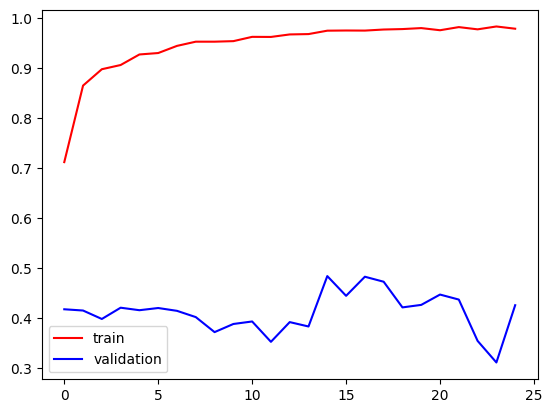

In [28]:
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'], color='red', label='train')
plt.plot(history.history['val_accuracy'], color='blue', label='validation')
plt.legend()
plt.show()

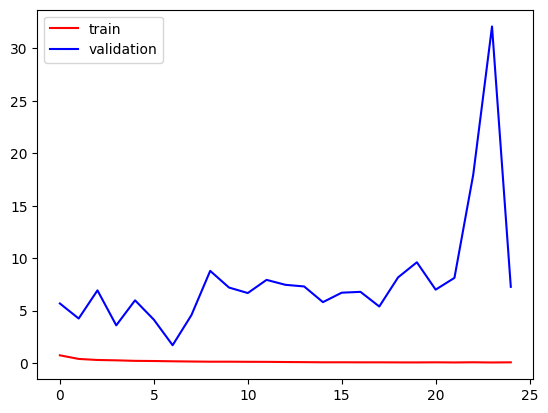

In [29]:
plt.plot(history.history['loss'], color='red', label='train')
plt.plot(history.history['val_loss'], color='blue', label='validation')
plt.legend()
plt.show()

In [30]:
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc
import seaborn as sns
from sklearn.preprocessing import label_binarize
from keras.models import load_model

In [31]:
test_predictions = model.predict(test_images)
predicted_labels = np.argmax(test_predictions, axis = 1)
print('Classification Report:')
print(classification_report(test_labels, predicted_labels))

50/50 ━━━━━━━━━━━━━━━━━━━━ 10s 200ms/step
Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.04      0.07       400
           1       0.41      0.89      0.56       400
           2       0.57      0.99      0.72       400
           3       0.94      0.04      0.08       400

    accuracy                           0.49      1600
   macro avg       0.71      0.49      0.36      1600
weighted avg       0.71      0.49      0.36      1600



Confusion Matrix:
[[ 14 316  69   1]
 [  1 356  43   0]
 [  0   4 396   0]
 [  0 195 189  16]]


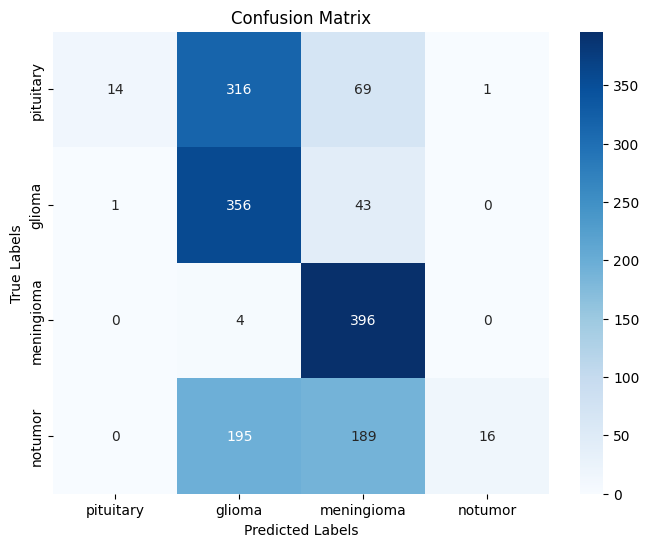

In [32]:
conf_matrix = confusion_matrix(test_labels, predicted_labels)
print("Confusion Matrix:")
print(conf_matrix)

plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues", xticklabels=os.listdir(train_dir), yticklabels=os.listdir(train_dir))
plt.title("Confusion Matrix")
plt.xlabel("Predicted Labels")
plt.ylabel("True Labels")
plt.show()

In [35]:
model.save('model.keras')

In [37]:
from tensorflow.keras.models import load_model
model = load_model('model.keras')

/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'rmsprop', because it has 12 variables whereas the saved optimizer has 22 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


In [38]:
class_labels = ['pituitary', 'glioma', 'notumor', 'meningioma']

def detect(img_path, model, image_size=256):
  try:
    img = load_img(img_path, target_size=(image_size, image_size))
    img_array = img_to_array(img) / 255.0
    img_array = np.expand_dims(img_array, axis=0)

    predictions = model.predict(img_array)
    predicted_class_index = np.argmax(predictions, axis=1)[0]
    confidence_score = np.max(predictions, axis=1)[0]

    if class_labels[predicted_class_index] == 'notumor':
        result = "No Tumor"
    else:
        result = f"Tumor: {class_labels[predicted_class_index]}"

    plt.imshow(load_img(img_path))
    plt.axis('off')
    plt.title(f"{result} (Confidence: {confidence_score * 100:.2f}%)")
    plt.show()

  except Exception as e:
        print("Error in processing the image:", str(e))

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 704ms/step


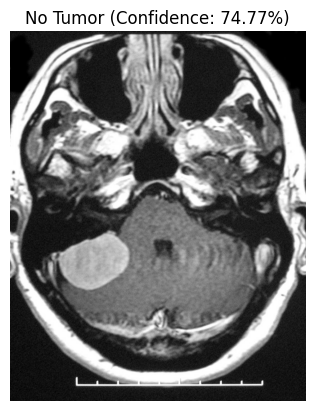

In [40]:
image_path = '/content/meningioma-tumor.jpg'
detect(image_path, model)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step


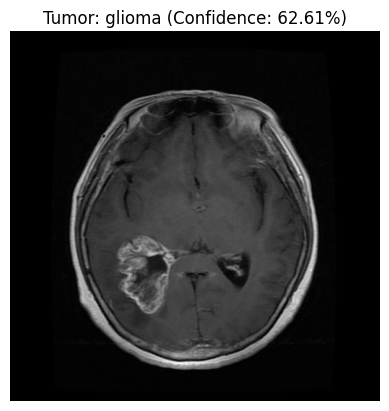

In [41]:
image_path = '/content/glioma-tumor.jpg'
detect(image_path, model)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step


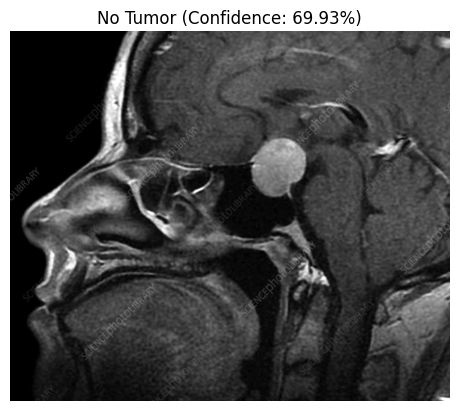

In [42]:
image_path = '/content/pituitary_tumor.jpeg'
detect(image_path, model)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step


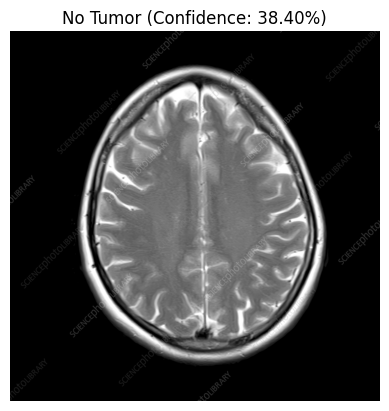

In [43]:
image_path = '/content/no-tumor.jpg'
detect(image_path, model)